# Цифровые технологии в профессиональной деятельности
## Раздел 1. Текст-майнинг
## Семинар 4. Стилометрия: дельта Бёрроуза

На лабораторной работе мы увидели, что TF-IDF выделяет **тематические** различия между текстами: о чём текст, какие понятия в нём ключевые. Стилометрия решает другую задачу: определить, **кто** написал текст, по неосознанным особенностям стиля — частоте служебных слов, длине предложений, синтаксическим привычкам. Сегодня мы разберём классический метод — **дельту Бёрроуза** (Burrows' Delta, 2002).

**Кейс:** в 2013 году лингвист Патрик Джулиола с помощью стилометрии установил, что детективы, опубликованные под псевдонимом Роберт Гэлбрейт, на самом деле написала Дж. К. Роулинг. Мы воспроизведём этот анализ.

_Cогласно требованиям филологической критики, отвержение авторства должно быть основано на данных рукописной традиции, свидетельствах современников, соответствии бытовых и исторических реалий времени жизни автора, а также на соответствии идей, тем и жанров тому, что известно по подлинным сочинениям автора. Стилистические и языковые особенности — лишь один, не главный и не единственный, инструмент исследователя, а из этих особенностей лишь некоторые могут быть описаны количественно._

Алиева О. В. *Pseudoplatonica: блеск и нищета стилометрии*

In [8]:
import re
import os
from collections import Counter
import requests

import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

---
## Часть 1. Подготовка корпуса

Наш корпус — тексты четырёх англоязычных авторов:
- **Толкин** — фэнтези (Властелин колец и др.)
- **Льюис** — фэнтези (Хроники Нарнии и др.)
- **Роулинг** — фэнтези (Гарри Поттер)
- **Кобен** — детективы

А также тексты, опубликованные под псевдонимом **Роберт Гэлбрейт** — детективы. Наша задача: определить, кто из четырёх авторов скрывается за псевдонимом.

In [11]:
names = ['breaker_coben.txt',
 'career_galbraith.txt',
 'child_rowling.txt',
 'cuckoo_ galbraith.txt',
 'dropshot_coben.txt',
 'fadeaway_coben.txt',
 'falsemove_coben.txt',
 'hobbit_tolkien.txt',
 'hp_1_rowling.txt',
 'hp_2_rowling.txt',
 'hp_3_rowling.txt',
 'hp_6_rowling.txt',
 'hp_7_rowling.txt',
 'leathal_galbraith.txt',
 'lord_1_tolkien.txt',
 'lord_2_lewis.txt',
 'lord_2_tolkien.txt',
 'lord_3_tolkien.txt',
 'narnia_1_lewis.txt',
 'narnia_3_lewis.txt',
 'narnia_4_lewis.txt',
 'narnia_5_lewis.txt',
 'narnia_6_lewis.txt',
 'narnia_7_lewis.txt',
 'silkworm_galbraith.txt',
 'tellnoone_coben.txt',
 'vacancy_rowling.txt']

url = 'https://github.com/always1ready/dh-tools/raw/refs/heads/main/data/04_seminar/'

texts = {} 
for name in names:
    # Делаем запрос к конкретному файлу
    response = requests.get(url + name)
    
    if response.status_code == 200:
        texts[name.replace('.txt', '')] = response.text
    else:
        print(f"Не удалось загрузить: {name}")

print(f"Успешно загружено текстов: {len(texts)}")

Успешно загружено текстов: 27


In [14]:
# Препроцессинг: оставляем только буквенные символы, приводим к нижнему регистру.
# Для текстов не нужна лемматизация —
# стилометрия работает с поверхностными формами (словоформами).

def preprocess_en(texts):
    """Очищает тексты: убирает пунктуацию, переносы строк, лишние пробелы."""
    cleaned = {}
    for title, text in texts.items():
        text = re.sub(r"\n", " ", text)            # переносы строк → пробелы
        text = re.sub(r"[^A-Za-z\s\-]", "", text)  # убираем всё кроме букв, пробелов, дефисов
        text = re.sub(r"\s+", " ", text)           # множественные пробелы → один
        cleaned[title] = text.lower().strip()
    return cleaned

texts = preprocess_en(texts)
print(f"Пример (первые 200 символов): {list(texts.values())[0][:200]}...")

Пример (первые 200 символов): harlan coben deal breaker by this like everything else is for anne acknowledgement the author wishes to thank sunandan b singh md chief medical examiner of bergen county new jersey bob richter rich he...


---
## Часть 2. Векторизация: от текста к числам

Чтобы сравнивать тексты математически, нужно представить их как наборы чисел. Мы берём **100 самых частотных словоформ** корпуса и для каждого текста считаем **относительную частоту** каждого слова (число вхождений / общее число слов).

Почему именно частотные слова? В стилометрии ключевую роль играют **функциональные слова** — артикли, предлоги, союзы, местоимения (*the, of, and, to, a, in, he, she, it, was*). Они:
- наиболее частотные (попадают в топ-100)
- не зависят от темы текста (в отличие от *quidditch* или *hobbit*)
- используются неосознанно — автор редко отдаёт отчёт, какие грамматические конструкции использует

In [23]:
# CountVectorizer считает абсолютные частоты слов
vectorizer = CountVectorizer(max_features=100)
count_matrix = vectorizer.fit_transform(texts.values())
print(count_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2623 stored elements and shape (27, 100)>
  Coords	Values
  (0, 14)	118
  (0, 80)	349
  (0, 44)	390
  (0, 39)	288
  (0, 22)	518
  (0, 73)	3634
  (0, 83)	1833
  (0, 54)	1168
  (0, 4)	1134
  (0, 34)	942
  (0, 16)	89
  (0, 56)	676
  (0, 50)	1260
  (0, 30)	1613
  (0, 96)	534
  (0, 87)	234
  (0, 3)	207
  (0, 32)	120
  (0, 98)	1330
  (0, 5)	154
  (0, 37)	1050
  (0, 97)	193
  (0, 2)	284
  (0, 10)	267
  (0, 90)	520
  :	:
  (26, 68)	442
  (26, 20)	185
  (26, 69)	207
  (26, 77)	438
  (26, 81)	278
  (26, 75)	416
  (26, 78)	687
  (26, 88)	196
  (26, 18)	392
  (26, 67)	2900
  (26, 31)	2842
  (26, 92)	193
  (26, 8)	210
  (26, 55)	241
  (26, 61)	307
  (26, 15)	94
  (26, 66)	194
  (26, 49)	132
  (26, 93)	248
  (26, 38)	452
  (26, 70)	2
  (26, 74)	350
  (26, 1)	205
  (26, 95)	63
  (26, 63)	1


In [24]:
# Превращаем разреженную матрицу в обычную таблицу
freq_df = pd.DataFrame(
    count_matrix.toarray(),
    index=texts.keys(),
    columns=vectorizer.get_feature_names_out()
).astype(float)

In [25]:
freq_df

,about,again,all,an,and,are,as,at,away,back,...,what,when,where,which,who,will,with,would,you,your
breaker_coben,308.0,120.0,284.0,207.0,1134.0,154.0,267.0,413.0,113.0,270.0,...,520.0,210.0,70.0,30.0,170.0,55.0,534.0,193.0,1330.0,262.0
career_galbraith,399.0,196.0,454.0,438.0,3304.0,141.0,946.0,822.0,227.0,417.0,...,517.0,441.0,289.0,287.0,461.0,34.0,1153.0,503.0,1174.0,150.0
child_rowling,120.0,70.0,187.0,83.0,1235.0,252.0,210.0,353.0,59.0,134.0,...,257.0,72.0,59.0,47.0,83.0,117.0,245.0,46.0,1067.0,219.0
cuckoo_ galbraith,458.0,191.0,541.0,510.0,3663.0,145.0,820.0,885.0,149.0,414.0,...,518.0,411.0,190.0,268.0,396.0,80.0,1195.0,324.0,1739.0,269.0
dropshot_coben,330.0,119.0,207.0,211.0,1080.0,122.0,215.0,430.0,83.0,183.0,...,526.0,199.0,64.0,26.0,165.0,68.0,458.0,160.0,1481.0,250.0
fadeaway_coben,346.0,164.0,307.0,214.0,1416.0,165.0,257.0,520.0,68.0,313.0,...,567.0,265.0,110.0,30.0,191.0,59.0,631.0,263.0,1692.0,252.0
falsemove_coben,299.0,154.0,212.0,194.0,1549.0,158.0,269.0,510.0,125.0,259.0,...,433.0,230.0,105.0,8.0,138.0,59.0,502.0,256.0,1343.0,314.0
hobbit_tolkien,216.0,192.0,664.0,125.0,4510.0,313.0,696.0,664.0,135.0,221.0,...,296.0,272.0,158.0,178.0,133.0,201.0,653.0,248.0,827.0,204.0
hp_1_rowling,222.0,83.0,359.0,214.0,1881.0,145.0,513.0,601.0,63.0,247.0,...,293.0,161.0,90.0,85.0,175.0,87.0,412.0,108.0,789.0,142.0
hp_2_rowling,200.0,118.0,394.0,194.0,2298.0,109.0,610.0,707.0,93.0,288.0,...,324.0,178.0,107.0,91.0,240.0,106.0,505.0,156.0,928.0,158.0


In [26]:
# Нормализуем: делим каждую строку на общее число слов в тексте
total_words = {name: len(text.split()) for name, text in texts.items()}
for name in freq_df.index:
    freq_df.loc[name] = freq_df.loc[name] / total_words[name]

In [27]:
freq_df

,about,again,all,an,and,are,as,at,away,back,...,what,when,where,which,who,will,with,would,you,your
breaker_coben,0.003678,0.001433,0.003392,0.002472,0.013542,0.001839,0.003189,0.004932,0.001349,0.003224,...,0.006210,0.002508,0.000836,0.000358,0.002030,0.000657,0.006377,0.002305,0.015883,0.003129
career_galbraith,0.002574,0.001265,0.002929,0.002826,0.021317,0.000910,0.006103,0.005303,0.001465,0.002690,...,0.003336,0.002845,0.001865,0.001852,0.002974,0.000219,0.007439,0.003245,0.007574,0.000968
child_rowling,0.002632,0.001536,0.004102,0.001821,0.027092,0.005528,0.004607,0.007744,0.001294,0.002940,...,0.005638,0.001579,0.001294,0.001031,0.001821,0.002567,0.005375,0.001009,0.023407,0.004804
cuckoo_ galbraith,0.003010,0.001255,0.003556,0.003352,0.024074,0.000953,0.005389,0.005816,0.000979,0.002721,...,0.003404,0.002701,0.001249,0.001761,0.002603,0.000526,0.007854,0.002129,0.011429,0.001768
dropshot_coben,0.004316,0.001556,0.002707,0.002759,0.014124,0.001595,0.002812,0.005623,0.001085,0.002393,...,0.006879,0.002602,0.000837,0.000340,0.002158,0.000889,0.005989,0.002092,0.019368,0.003269
fadeaway_coben,0.003929,0.001862,0.003486,0.002430,0.016081,0.001874,0.002919,0.005905,0.000772,0.003555,...,0.006439,0.003009,0.001249,0.000341,0.002169,0.000670,0.007166,0.002987,0.019215,0.002862
falsemove_coben,0.003691,0.001901,0.002617,0.002395,0.019119,0.001950,0.003320,0.006295,0.001543,0.003197,...,0.005345,0.002839,0.001296,0.000099,0.001703,0.000728,0.006196,0.003160,0.016577,0.003876
hobbit_tolkien,0.002268,0.002016,0.006971,0.001312,0.047351,0.003286,0.007307,0.006971,0.001417,0.002320,...,0.003108,0.002856,0.001659,0.001869,0.001396,0.002110,0.006856,0.002604,0.008683,0.002142
hp_1_rowling,0.002967,0.001109,0.004798,0.002860,0.025139,0.001938,0.006856,0.008032,0.000842,0.003301,...,0.003916,0.002152,0.001203,0.001136,0.002339,0.001163,0.005506,0.001443,0.010545,0.001898
hp_2_rowling,0.002242,0.001323,0.004417,0.002175,0.025761,0.001222,0.006838,0.007926,0.001043,0.003229,...,0.003632,0.001995,0.001200,0.001020,0.002690,0.001188,0.005661,0.001749,0.010403,0.001771


Соберём всё это в функцию для дальнейшего использования!

In [29]:
def vectorize(texts, max_features=100):
    """
    Векторизует тексты: считает относительные частоты топ-N слов.
    
    Возвращает DataFrame: строки = тексты, столбцы = слова, значения = частоты.
    """
    # CountVectorizer считает абсолютные частоты слов
    vectorizer = CountVectorizer(max_features=max_features)
    count_matrix = vectorizer.fit_transform(texts.values())
    
    # Превращаем разреженную матрицу в обычную таблицу
    freq_df = pd.DataFrame(
        count_matrix.toarray(),
        index=texts.keys(),
        columns=vectorizer.get_feature_names_out()
    ).astype(float)
    
    # Нормализуем: делим каждую строку на общее число слов в тексте
    total_words = {name: len(text.split()) for name, text in texts.items()}
    for name in freq_df.index:
        freq_df.loc[name] = freq_df.loc[name] / total_words[name]
    
    return freq_df

In [30]:
freq_df = vectorize(texts, max_features=100)
print(f"Таблица частот: {freq_df.shape[0]} текстов × {freq_df.shape[1]} слов")
freq_df.head()

Таблица частот: 27 текстов × 100 слов


,about,again,all,an,and,are,as,at,away,back,...,what,when,where,which,who,will,with,would,you,your
breaker_coben,0.003678,0.001433,0.003392,0.002472,0.013542,0.001839,0.003189,0.004932,0.001349,0.003224,...,0.006210,0.002508,0.000836,0.000358,0.002030,0.000657,0.006377,0.002305,0.015883,0.003129
career_galbraith,0.002574,0.001265,0.002929,0.002826,0.021317,0.000910,0.006103,0.005303,0.001465,0.002690,...,0.003336,0.002845,0.001865,0.001852,0.002974,0.000219,0.007439,0.003245,0.007574,0.000968
child_rowling,0.002632,0.001536,0.004102,0.001821,0.027092,0.005528,0.004607,0.007744,0.001294,0.002940,...,0.005638,0.001579,0.001294,0.001031,0.001821,0.002567,0.005375,0.001009,0.023407,0.004804
cuckoo_ galbraith,0.003010,0.001255,0.003556,0.003352,0.024074,0.000953,0.005389,0.005816,0.000979,0.002721,...,0.003404,0.002701,0.001249,0.001761,0.002603,0.000526,0.007854,0.002129,0.011429,0.001768
dropshot_coben,0.004316,0.001556,0.002707,0.002759,0.014124,0.001595,0.002812,0.005623,0.001085,0.002393,...,0.006879,0.002602,0.000837,0.000340,0.002158,0.000889,0.005989,0.002092,0.019368,0.003269


Обратите внимание на столбцы: *the, and, of, to, was, her, he, in...* — это именно служебные слова. TF-IDF бы их отбросил (они встречаются во всех текстах, IDF ≈ 0), а стилометрия на них опирается.

---
## Часть 3. Z-score: зачем стандартизировать

### Проблема

Представим, что мы хотим сравнить два текста по частоте слов. Возьмём игрушечный пример с тремя словами.

In [31]:
# Игрушечный пример: частоты слов в двух текстах
toy = pd.DataFrame({
    'the': [100, 120],       # очень частотное слово
    'quidditch': [5, 15],    # редкое слово
    'wand': [10, 12]         # средне частотное слово
}, index=['Text_A', 'Text_B'])

toy

,the,quidditch,wand
Text_A,100,5,10
Text_B,120,15,12


In [32]:
# Если просто посчитать разницу:
diff = toy.loc['Text_A'] - toy.loc['Text_B']
print(diff)

# Разница по «the» = 20, по «wand» = 2, по «quidditch» = 10.
# Кажется, что «the» важнее всего для различения текстов.
# Но это обман: «the» просто частотнее, разброс у него больше.

the         -20
quidditch   -10
wand         -2
dtype: int64


### Решение: z-score

**Z-score** стандартизирует каждое значение относительно распределения данного слова по всему корпусу:

$$z = \frac{x - \mu}{\sigma}$$

где $x$ — частота слова в тексте, $\mu$ — средняя частота слова по корпусу, $\sigma$ — стандартное отклонение.

После стандартизации все слова оказываются на одной шкале: z-score показывает, **на сколько стандартных отклонений** частота слова в данном тексте отличается от средней.

In [33]:
# Считаем z-score для игрушечного примера
mean = toy.mean()   # среднее по столбцу (по всем текстам)
std = toy.std()     # стандартное отклонение по столбцу

print("Средние:", dict(mean))
print("Стд. откл.:", dict(std.round(2)))
print()

z_scores = (toy - mean) / std
z_scores

Средние: {'the': np.float64(110.0), 'quidditch': np.float64(10.0), 'wand': np.float64(11.0)}
Стд. откл.: {'the': np.float64(14.14), 'quidditch': np.float64(7.07), 'wand': np.float64(1.41)}



,the,quidditch,wand
Text_A,-0.707107,-0.707107,-0.707107
Text_B,0.707107,0.707107,0.707107


Теперь видно: отклонение по *the* и *quidditch* одинаковое по модулю (≈ 0.71). Стандартизация убрала эффект масштаба — слова стали сравнимыми.

---
## Часть 4. Дельта Бёрроуза

Дельта Бёрроуза — это **средняя абсолютная разница z-score** между двумя текстами по всем словам:

$$\Delta(A, B) = \frac{1}{n} \sum_{i=1}^{n} |z_{A,i} - z_{B,i}|$$

Может быть, картинка будет нагляднее:
![Это дельта](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSvhQ1z5YArJEsG1tb6VxrMrzZ1JehhsbVarw&s)

где $n$ — число слов (признаков), $z_{A,i}$ и $z_{B,i}$ — z-score слова $i$ в текстах $A$ и $B$.

Чем **меньше** дельта между двумя текстами, тем они **ближе** по стилю. Если два текста написаны одним автором, дельта между ними должна быть маленькой.

In [34]:
def calculate_delta(frequency_table):
    """
    Рассчитывает матрицу расстояний по дельте Бёрроуза.
    
    Шаги:
    1. Стандартизируем частоты (z-score)
    2. Считаем попарные Manhattan-расстояния
    3. Нормируем на число слов
    
    Возвращает DataFrame (матрица расстояний).
    """
    # 1. Z-score: стандартизируем каждое слово по корпусу
    std_values = frequency_table.std().replace(0, 0.1)  # защита от деления на 0
    z_scores = (frequency_table - frequency_table.mean()) / std_values
    
    # 2. Manhattan-расстояние = сумма модулей разностей
    #    Это то же самое, что сумма |z_A - z_B| для всех слов
    distances = pairwise_distances(z_scores, metric='manhattan')
    
    # 3. Нормируем: делим на число слов, чтобы получить среднюю разницу
    n_words = frequency_table.shape[1]
    distances = distances / n_words
    
    return pd.DataFrame(distances,
                        index=frequency_table.index,
                        columns=frequency_table.index)

# Считаем дельту для нашего корпуса
delta_distances = calculate_delta(freq_df)
print(f"Матрица расстояний: {delta_distances.shape}")

Матрица расстояний: (27, 27)


In [ ]:
def calculate_delta(frequency_table):
    """
    ТО ЖЕ САМОЕ с использованием sklearn
    """
    std_values = frequency_table.std().replace(0, 0.1)
    z_scores = (frequency_table - frequency_table.mean()) / std_values
    
    # попарные расстояния с библиотекой sklearn
    distances = pairwise_distances(z_scores, metric='manhattan')
    
    # Нормируем на количество слов
    n_words = frequency_table.shape[1]
    distances = distances / n_words
    
    df = pd.DataFrame(distances, 
                        index=frequency_table.index, 
                        columns=frequency_table.index)
    
    return df

---
## Часть 5. Визуализация

### Heatmap — тепловая карта расстояний

Чем **темнее** ячейка, тем **ближе** тексты по стилю.

Та же самая функция рассчёта, но с использованием sklearn

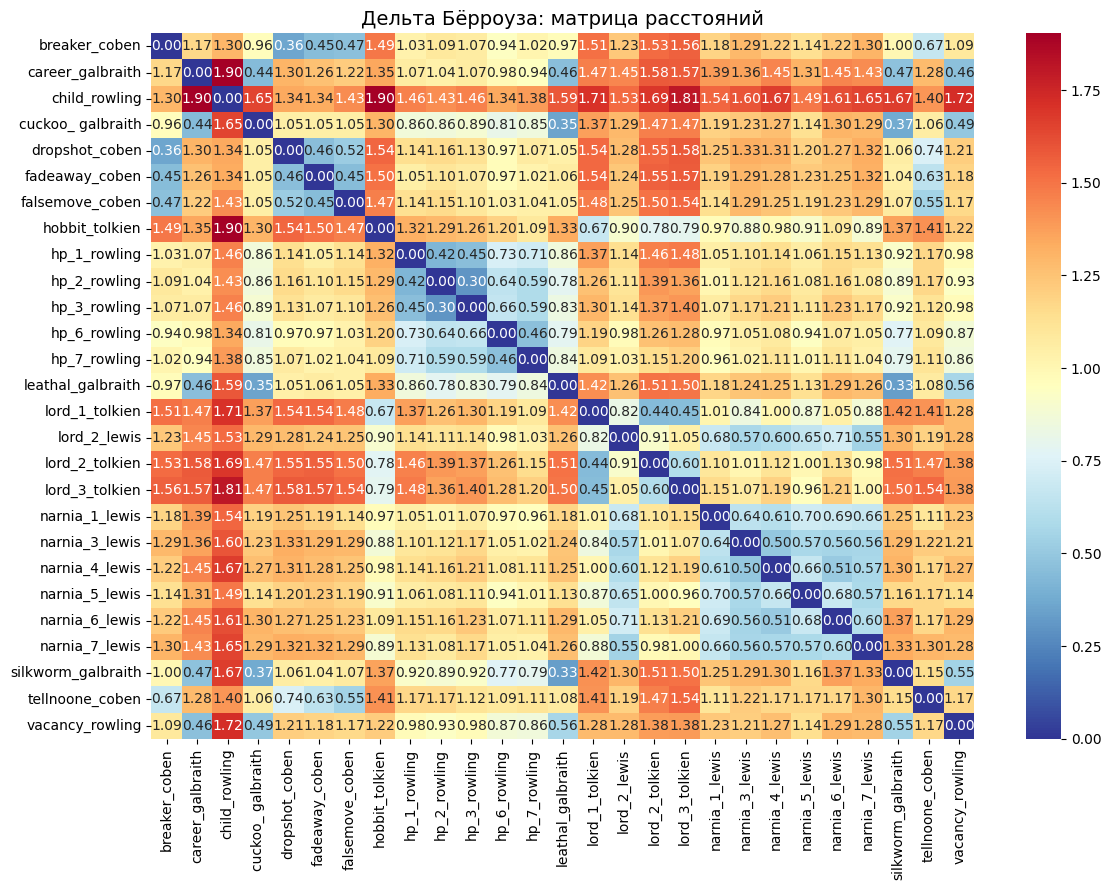

In [ ]:
# ===== HEATMAP =====
plt.figure(figsize=(12, 9))

# sns.heatmap рисует тепловую карту.
# annot=True — показывает числа в ячейках
# fmt='.2f' — формат чисел (2 знака после запятой)
# cmap='RdYlBu_r' — цветовая палитра (красный = далеко, синий = близко)
sns.heatmap(delta_distances, annot=True, fmt='.2f', cmap='RdYlBu_r')

plt.title('Дельта Бёрроуза: матрица расстояний', fontsize=14)
plt.tight_layout()
plt.show()

#### Задание 1
Посмотрите на тепловую карту. К какому автору ближе всего тексты Гэлбрейт? Совпадает ли это с известной нам историей?

In [ ]:
# Найдём ближайших авторов для каждого текста
for name in delta_distances.index:
    distances = delta_distances.loc[name].sort_values()
    closest = distances.index[1]  # [0] — сам текст (расстояние 0)
    print(f"{name:30s} → ближайший: {closest} ({distances.iloc[1]:.2f})")

### Дендрограмма — иерархическая кластеризация

Дендрограмма показывает, как тексты группируются по стилистической близости. Тексты одного автора должны оказаться на одной ветви.

Алгоритм: каждый текст — отдельный кластер. На каждом шаге два ближайших кластера объединяются. Процесс повторяется, пока не останется один кластер. Высота соединения на графике = расстояние между объединяемыми кластерами.

Проведём **агломеративную иерархическую кластеризацию** матрицы расстояний и отразим близость между документами на **дендрограмме** - классическом способе визуализации при решении стилометрических задач.

> Как устроена иерархическая кластеризация?

Каждый текст — отдельный кластер (всего 5 кластеров). Находим два самых близких текста и объединяем их в один кластер. Пересчитываем расстояния от нового кластера до всех остальных (способ пересчёта зависит от метода linkage — об этом ниже). Повторяем, пока не останется один кластер.

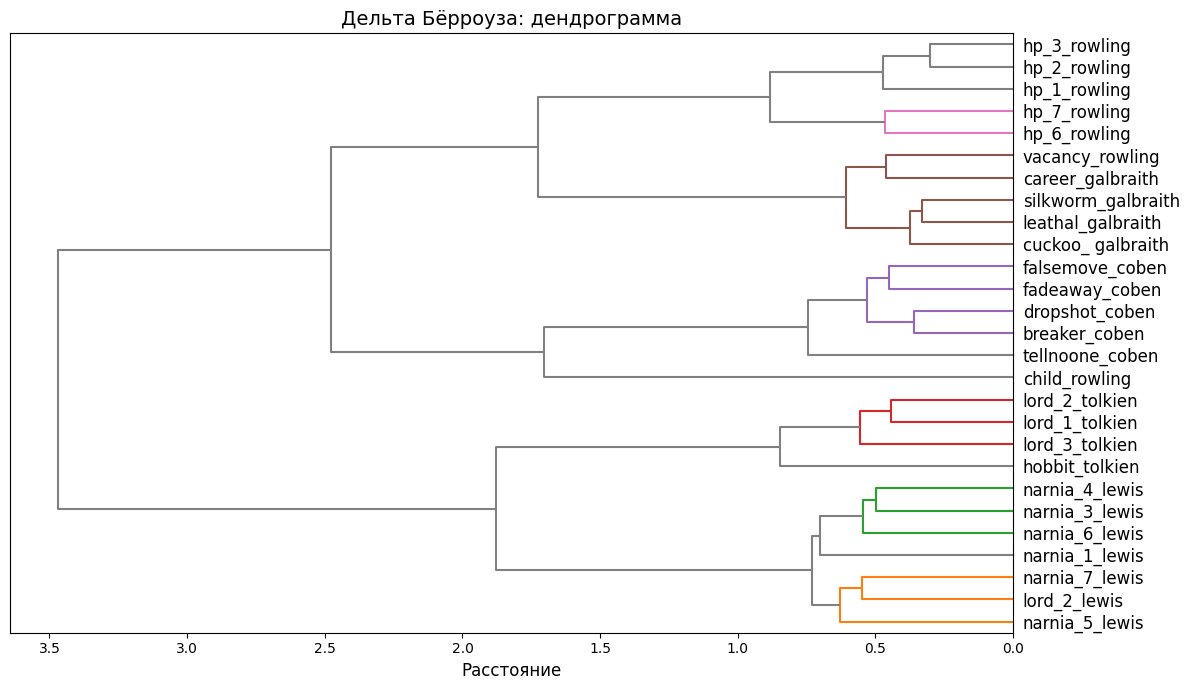

In [36]:
# ===== ДЕНДРОГРАММА =====

# squareform превращает квадратную матрицу расстояний в компактный вектор
# (убирает диагональ и дубликаты, т.к. матрица симметричная)
dist_vector = squareform(delta_distances.values)

# linkage выполняет кластеризацию.
# method='ward' — объединяет кластеры так, чтобы минимизировать
# внутрикластерную дисперсию (разброс внутри группы).
linkage_matrix = linkage(dist_vector, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(
    linkage_matrix,
    labels=delta_distances.index.tolist(),
    orientation='left',       # горизонтальная ориентация
    leaf_font_size=12,
    color_threshold=0.7,      # порог для раскраски ветвей
    above_threshold_color='gray'
)
plt.title('Дельта Бёрроуза: дендрограмма', fontsize=14)
plt.xlabel('Расстояние', fontsize=12)
plt.tight_layout()
plt.show()

#### Задание 2
Посмотрите на дендрограмму. Образуют ли тексты одного автора кластер? Где оказались тексты Гэлбрейт?

---
## Часть 6. Обсуждение

#### Задание 3
Сравните результаты лабораторной (TF-IDF на конституциях) и стилометрии (дельта Бёрроуза на Галбрайт). Ответьте на вопросы:

1. TF-IDF работает с **содержательными** словами (существительные, прилагательные), а дельта — с **функциональными** (артикли, предлоги, местоимения). Почему для определения авторства важнее вторые?

2. Какие ограничения стилометрии обсуждает Алиева в статье? Согласны ли вы с ними?

3. Можно ли применить дельту Бёрроуза к текстам на русском языке? Какие сложности могут возникнуть?

---
### Итоги

Сегодня мы:
1. Разобрали z-score — зачем стандартизировать частоты перед сравнением
2. Освоили дельту Бёрроуза — классический метод стилометрии
3. Воспроизвели атрибуцию текстов Гэлбрейт (Роулинг) по дельте
4. Обсудили ограничения количественных методов атрибуции